# Norway vs France match prediction (2026-06-26)

Predicts Norway's third World Cup group match with the project's two-model core:

* **Logistic regression** — clean W/D/L probabilities
* **Poisson** — football-specific scoreline probabilities (expected goals to scoreline grid).



## 1. Setup

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd

# Make the project importable whether this runs from notebooks/ or the project root.
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))

from scipy.stats import poisson

from src.data_collection import build_inputs
from src.preprocessing import load_data as L
from src.features import build_features as F
from src.models import logistic_model as LM
from src.models import poisson_model as P
from src.models.logistic_model import proba_frame
from src.utils.config import FIXTURES, RESULT_CLASSES

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

## 2. Build dataset

The Norway vs France fixture is `FIXTURES[2]`.


In [2]:
build_inputs.build_all(force=False)

matches = L.load_matches()
flashscore = L.repair_flashscore(L.load_flashscore(), matches)
fifa = L.load_fifa()
elo = L.load_elo()

persp_feat, model_dataset, all_team_dataset, fixture_dataset = F.engineer(
    matches, elo, fifa, flashscore, FIXTURES)

print("fixtures available:", sorted(fixture_dataset["match_id"].unique()))

21:31:20 | INFO    | src.data_collection.build_inputs | matches.csv + elo_ratings.csv present - skipping eloratings
21:31:20 | INFO    | src.data_collection.build_inputs | fifa_rankings.csv present - skipping
21:31:20 | INFO    | src.data_collection.build_inputs | flashscore_stats.csv present - skipping
21:31:20 | INFO    | src.preprocessing.load_data | loaded 4642 matches (2020-12-04 -> 2026-06-23)
21:31:20 | INFO    | src.preprocessing.load_data | loaded 506 Flashscore team-match rows (106 teams)
21:31:20 | INFO    | src.preprocessing.load_data | Flashscore repair: checked 234 paired matches, swapped 45, nulled 0 unfixable single rows
21:31:21 | INFO    | src.preprocessing.load_data | team-perspective rows: 9284 (4642 matches x 2 sides)
21:31:21 | INFO    | src.preprocessing.load_data | attached Flashscore stats (xg coverage: 179/9284 perspective rows)
21:31:53 | INFO    | src.features.build_features | model dataset: 293 focus rows | 9292 all-team rows | 6 fixture rows
fixtures avail

## 2b. Updated evidence (matchday 1 and 2)

The opening group results and the resulting Elo moves now sit in the inputs. Norway's
4–1 win over Iraq and France's 3–1 win over Senegal both shift the pre-match Elo gap
and the recent-form signal that the models actually read.


In [3]:
md1 = matches[matches["date"] == "2026-06-22"]
print("Matchday 2 results now in matches.csv:")
print(md1[["date", "home_team", "away_team", "home_score", "away_score",
          "competition_type", "neutral"]].to_string(index=False))

print("\nLatest Elo per team (post matchday 2):")
for t in ["Norway", "Senegal", "France", "Iraq"]:
    last2 = elo[elo["team"] == t].sort_values("date").tail(2)
    moves = "  ->  ".join(f"{r.date.date()}: {r.elo:.0f}" for r in last2.itertuples())
    print(f"  {t:8s} {moves}")

nor_elo = elo[elo["team"] == "Norway"].sort_values("date")["elo"].iloc[-1]
sen_elo = elo[elo["team"] == "France"].sort_values("date")["elo"].iloc[-1]
print(f"\nNorway - France Elo gap: {nor_elo - sen_elo:+.0f}")

Matchday 2 results now in matches.csv:
      date home_team away_team  home_score  away_score competition_type  neutral
2026-06-22    France      Iraq           3           0        world_cup     True

Latest Elo per team (post matchday 2):
  Norway   2026-06-16: 1929  ->  2026-06-23: 1951
  Senegal  2026-06-16: 1839  ->  2026-06-23: 1817
  France   2026-06-16: 2084  ->  2026-06-23: 2090
  Iraq     2026-06-09: 1607  ->  2026-06-16: 1592

Norway - France Elo gap: -139


## 3. Fit the two core models

* **Logistic** is trained on the broader all-team dataset (more rows → better-calibrated
  probabilities; this is what the pipeline uses).
* **Poisson** attack/defence strengths are computed from team-perspective goal rates.

In [4]:
fitted = LM.fit_final(model_dataset, train_override=all_team_dataset)
model, feats = fitted["logistic"]

mu, strengths = P.compute_strengths(persp_feat)
print(f"logistic trained on {len(all_team_dataset):,} rows | "
      f"Poisson league avg = {mu:.2f} goals/team/match")

c:\Users\karoo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


21:31:54 | INFO    | src.models.logistic_model | fitted logistic on 9292 rows (half-life=1095 d)
21:31:54 | INFO    | src.models.poisson_model | Poisson strengths: 201 teams, league avg = 1.32 goals/team/match
logistic trained on 9,292 rows | Poisson league avg = 1.32 goals/team/match


## 4. Predict match

Norway is the nominal home side (listed first), but the venue is neutral, so the
home-advantage multiplier is switched off (`is_home=1, is_neutral=1` → no boost),
exactly as the pipeline scores it. We score the fixture from Norway's perspective;
Senegal's win probability is simply Norway's loss probability.

In [5]:
fixture = FIXTURES[2]
TEAM, OPP, DATE = fixture["team"], fixture["opponent"], fixture["date"]
MID = f"FIX_{TEAM}_{OPP}_{DATE}"

row = fixture_dataset[(fixture_dataset["match_id"] == MID) & (fixture_dataset["team"] == TEAM)]
assert len(row) == 1, f"expected one {TEAM} row for {MID}, got {len(row)}"

# Logistic W/D/L (Norway's perspective).
log_p = proba_frame(model, row[feats]).iloc[0]

# Poisson W/D/L + expected goals. Neutral venue -> home advantage cancels.
p = fixture.get("is_home", 1)
n = fixture.get("is_neutral", 1)
pois = P.predict(strengths, mu, TEAM, OPP, is_home=int(p), is_neutral=int(n))

# Ensemble = mean(logistic, Poisson), same as the pipeline.
ens = {c: (float(log_p[c]) + float(pois[c])) / 2 for c in RESULT_CLASSES}

labels = {
    "win": f"{TEAM} win",
    "draw": "Draw",
    "loss": f"{OPP} win",
}
table = pd.DataFrame({
    f"{TEAM} win": [log_p["win"], pois["win"], ens["win"]],
    "Draw":        [log_p["draw"], pois["draw"], ens["draw"]],
    f"{OPP} win": [log_p["loss"], pois["loss"], ens["loss"]],
}, index=["logistic", "poisson", "ensemble"])
(table * 100).round(1)


,Norway win,Draw,France win
logistic,22.6,29.8,47.7
poisson,35.8,23.6,40.6
ensemble,29.2,26.7,44.1


## 5. Predicted scoreline (Poisson)

The two expected-goal rates (λ) define an independent Poisson grid over scorelines.
Below, we have each side's expected goals, the probability of every scoreline 0–5 (in %,
Norway down the rows, Senegal across the columns), and the most likely results.

In [6]:
lam_nor, lam_sen = pois["lam_team"], pois["lam_opp"]
print(f"Expected goals  ->  {TEAM} {lam_nor:.2f}   |   {OPP} {lam_sen:.2f}")

MAXG = 5
a = poisson.pmf(np.arange(MAXG + 1), lam_nor)
b = poisson.pmf(np.arange(MAXG + 1), lam_sen)
grid = np.outer(a, b)  # rows = Norway goals, cols = Senegal goals

grid_df = pd.DataFrame(
    grid,
    index=pd.Index(range(MAXG + 1), name=TEAM),
    columns=pd.Index(range(MAXG + 1), name=OPP),
)
# Cell = P(exact scoreline), %. (0-5 view; tail beyond 5 goals omitted, so rows
# need not sum to exactly 100.)
(grid_df * 100).round(1)


Expected goals  ->  Norway 1.52   |   France 1.63


France,0,1,2,3,4,5
Norway,,,,,,
0,4.3,7.0,5.7,3.1,1.3,0.4
1,6.5,10.6,8.7,4.7,1.9,0.6
2,5.0,8.1,6.6,3.6,1.4,0.5
3,2.5,4.1,3.3,1.8,0.7,0.2
4,1.0,1.5,1.3,0.7,0.3,0.1
5,0.3,0.5,0.4,0.2,0.1,0.0


In [7]:
# Top-5 most likely scorelines (Norway-France).
flat = [(f"{i}-{j}", grid[i, j]) for i in range(MAXG + 1) for j in range(MAXG + 1)]
top5 = (pd.DataFrame(flat, columns=[f"{TEAM}-{OPP}", "probability"])
        .sort_values("probability", ascending=False)
        .head(5)
        .reset_index(drop=True))
top5["probability"] = (top5["probability"] * 100).round(1)
top5


,Norway-France,probability
0,1-1,10.6
1,1-2,8.7
2,2-1,8.1
3,0-1,7.0
4,2-2,6.6


## 6. Verdict

In [8]:
i, j = pois["score"]
verdict = {"win": f"{TEAM} win", "draw": "Draw", "loss": f"{OPP} win"}[max(ens, key=ens.get)]

print(f"{TEAM} vs {OPP}  -  {DATE}  (neutral venue)")
print("-" * 48)
print(f"  {TEAM} win    {ens['win']*100:4.0f}%")
print(f"  Draw          {ens['draw']*100:4.0f}%")
print(f"  {OPP} win     {ens['loss']*100:4.0f}%")
print(f"  -> consensus: {verdict}")
print(f"  Most likely scoreline: {TEAM} {i}-{j} {OPP}")
print(f"  Expected goals: {TEAM} {lam_nor:.2f} | {OPP} {lam_sen:.2f}")


Norway vs France  -  2026-06-26  (neutral venue)
------------------------------------------------
  Norway win      29%
  Draw            27%
  France win       44%
  -> consensus: France win
  Most likely scoreline: Norway 1-1 France
  Expected goals: Norway 1.52 | France 1.63


## 7. Feature importance (logistic model)

Because the logistic model standardizes its inputs, the **magnitude of each
coefficient is a fair importance measure** and its sign gives direction. The chart
shows the standardized coefficients for the *Norway-win* class — bar length = how
strongly a feature drives P(Norway win), green = pushes toward a Norway win, red =
away. The table lists the full per-class coefficients ranked by overall importance
(mean |coef| across win/draw/loss).

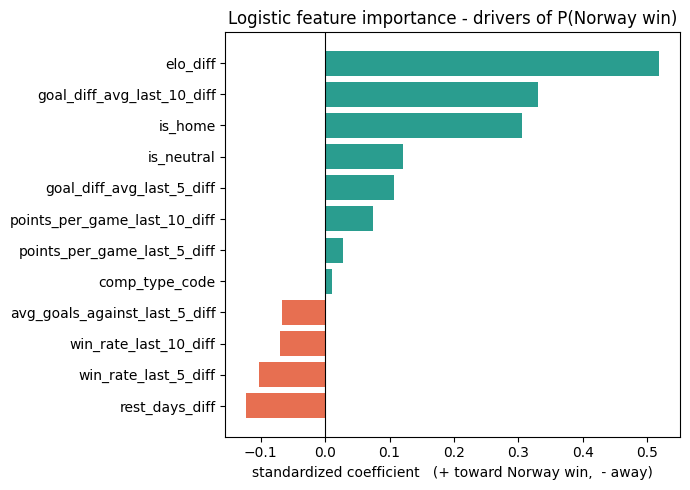

,draw,loss,win,importance
elo_diff,0.000,-0.519,0.519,0.346
goal_diff_avg_last_10_diff,0.000,-0.330,0.330,0.220
is_home,-0.000,-0.305,0.305,0.203
is_neutral,0.063,-0.185,0.122,0.123
rest_days_diff,-0.000,0.123,-0.123,0.082
goal_diff_avg_last_5_diff,0.000,-0.107,0.107,0.071
win_rate_last_5_diff,0.002,0.100,-0.102,0.068
points_per_game_last_10_diff,0.001,-0.075,0.074,0.050
win_rate_last_10_diff,-0.001,0.070,-0.069,0.047
avg_goals_against_last_5_diff,0.000,0.067,-0.067,0.045


In [9]:
import matplotlib.pyplot as plt

# The logistic pipeline standardizes its inputs, so coefficient size = importance.
clf = model.named_steps["clf"]
classes = list(clf.classes_)                        # ['draw', 'loss', 'win']
coef_df = pd.DataFrame(clf.coef_.T, index=feats, columns=classes)
coef_df["importance"] = coef_df[classes].abs().mean(axis=1)

# Standardized coefficients for the Norway-win class:
# bar length = importance, sign = direction.
win_coef = coef_df["win"].sort_values()
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in win_coef.values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(win_coef.index, win_coef.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized coefficient   (+ toward Norway win,  - away)")
ax.set_title("Logistic feature importance - drivers of P(Norway win)")
plt.tight_layout()
plt.show()

# Full per-class coefficients, ranked by overall importance (mean |coef|).
coef_df.sort_values("importance", ascending=False).round(3)

---

**How to read this.** Probabilities are directional, not certainties. Consistent
findings for this project: **Elo dominates** the signal, **draws are hard** to call
as the single most likely outcome (a known property of 3-class football models),
and the advanced Flashscore stats are descriptive only (they do not feed the
logistic or Poisson models). With the opening group results in the books, Norway
enter this game off a 4–1 win and France off a 3–1 win — reflected in a wider
Elo gap. The sample is small — treat the numbers as a reasoned lean, not a guarantee.
